In [7]:
from sklearn.ensemble import BaggingClassifier, VotingClassifier, RandomForestClassifier, GradientBoostingClassifier, StackingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# === Load Data ===
df = pd.read_csv("../winequality-red.csv")

# === Prepare Data ===
X = df.drop('quality', axis=1)
y = df['quality']  # For simplicity, treat as multiclass classification

# Optionally, binarize or group quality for binary classification
# y = (df['quality'] >= 7).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
# === Label Encode the target ===
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

In [10]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Bagging": BaggingClassifier(DecisionTreeClassifier(), n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=50, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
    "Voting (Soft)": VotingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
            ('svc', SVC(probability=True, random_state=42))
        ],
        voting='soft'
    ),
    "Stacking (Simple)": StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
            ('svc', SVC(probability=True, random_state=42))
        ],
        final_estimator=LogisticRegression(max_iter=1000, random_state=42),
        cv=5,
        n_jobs=-1
    ),
    "Stacking (Advanced)": StackingClassifier(
        estimators=[
            ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
            ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
            ('svc', SVC(probability=True, random_state=42)),
            ('knn', KNeighborsClassifier()),
            ('ada', AdaBoostClassifier(n_estimators=50, random_state=42))
        ],
        final_estimator=XGBClassifier(n_estimators=50, use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        cv=5,
        n_jobs=-1
    )
}

In [11]:
results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train_enc)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test_enc, y_pred)
    cv = cross_val_score(model, X_train, y_train_enc, cv=5).mean()
    
    results.append({
        'Model': name,
        'Accuracy': acc,
        'CV Score (mean)': cv
    })

    # Optional: detailed report
    print(f"\nClassification report for {name}:")
    print(classification_report(le.inverse_transform(y_test_enc), le.inverse_transform(y_pred)))


Training Random Forest...

Classification report for Random Forest:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.76      0.73       136
           6       0.65      0.70      0.67       128
           7       0.71      0.55      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.43      0.39      0.40       320
weighted avg       0.65      0.68      0.66       320

Training Bagging...


c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification report for Bagging:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.70      0.75      0.73       136
           6       0.63      0.70      0.67       128
           7       0.76      0.55      0.64        40
           8       0.33      0.33      0.33         3

    accuracy                           0.67       320
   macro avg       0.40      0.39      0.39       320
weighted avg       0.65      0.67      0.66       320

Training AdaBoost...


c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: Fut


Classification report for AdaBoost:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.59      0.73      0.65       136
           6       0.53      0.48      0.51       128
           7       0.50      0.15      0.23        40
           8       0.04      0.33      0.07         3

    accuracy                           0.53       320
   macro avg       0.28      0.28      0.24       320
weighted avg       0.53      0.53      0.51       320

Training Gradient Boosting...

Classification report for Gradient Boosting:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.25      0.09      0.13        11
           5       0.68      0.71      0.70       136
           6       0.64      0.65      0.64       128
           7       0.63      0.65      0.64        40
           8       

...

c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Classification report for Stacking (Simple):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.71      0.73      0.72       136
           6       0.62      0.72      0.66       128
           7       0.68      0.53      0.59        40
           8       0.00      0.00      0.00         3

    accuracy                           0.66       320
   macro avg       0.33      0.33      0.33       320
weighted avg       0.63      0.66      0.64       320

Training Stacking (Advanced)...


c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:39:


Classification report for Stacking (Advanced):
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.72      0.77      0.74       136
           6       0.65      0.68      0.66       128
           7       0.65      0.60      0.62        40
           8       0.00      0.00      0.00         3

    accuracy                           0.68       320
   macro avg       0.34      0.34      0.34       320
weighted avg       0.65      0.68      0.66       320



c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [12]:
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("\n🔍 Final Comparison Table:\n")
print(results_df)



🔍 Final Comparison Table:

                 Model  Accuracy  CV Score (mean)
5        Voting (Soft)  0.687500         0.670034
0        Random Forest  0.678125         0.671599
7  Stacking (Advanced)  0.675000         0.647341
1              Bagging  0.671875         0.675509
4              XGBoost  0.662500         0.664547
6    Stacking (Simple)  0.662500         0.671612
3    Gradient Boosting  0.650000         0.655187
2             AdaBoost  0.525000         0.561366


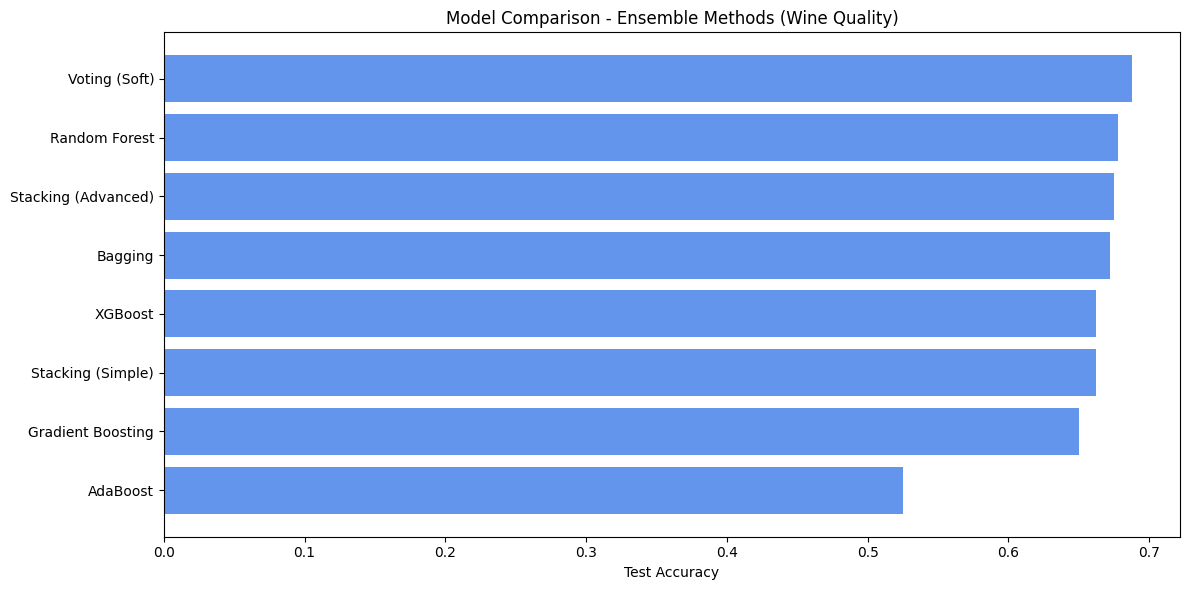

In [13]:
plt.figure(figsize=(12, 6))
plt.barh(results_df['Model'], results_df['Accuracy'], color='cornflowerblue')
plt.xlabel("Test Accuracy")
plt.title("Model Comparison - Ensemble Methods (Wine Quality)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
